In [8]:
import os
import re
import math
from PIL import Image, ImageOps, ImageDraw

def extract_time_point(filename):
    """
    Extracts the integer after '_t' from the filename using regex.
    Example: 'Rumbaugh_e19_60X_targetoverview_t0_C01_s0_w0_z20' -> 0
    """
    match = re.search(r'_t(\d+)', filename)
    if match:
        return int(match.group(1))
    return float('inf')  # Push files without a 't' tag to the end

def create_time_labeled_tiles(
    folder_path, 
    output_path, 
    crop_box,         # (X, Y, Width, Height)
    columns=None, 
    spacing=10,       
    border_width=3,   
    bg_color=(255, 255, 255)
):
    """
    Sorts images by their '_t' timestamp parameter, crops a custom subset,
    adds a black border, burns a 't=X' label onto the tile, and arranges them in a grid.
    """
    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.webp', '.tif', '.tiff')
    
    # Get all image files
    raw_files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]
    
    if not raw_files:
        print(f"No valid images found in '{folder_path}'")
        return

    # Sort files chronologically based on the extracted 't' value
    raw_files.sort(key=extract_time_point)
    image_files = [os.path.join(folder_path, f) for f in raw_files]

    num_images = len(image_files)
    print(f"Found {num_images} images ordered by time series. Processing...")

    if columns is None:
        columns = math.ceil(math.sqrt(num_images))
    rows = math.ceil(num_images / columns)

    crop_x, crop_y, crop_w, crop_h = crop_box
    tile_width, tile_height = crop_w, crop_h

    effective_width = tile_width + (2 * border_width)
    effective_height = tile_height + (2 * border_width)

    grid_width = (columns * effective_width) + ((columns + 1) * spacing)
    grid_height = (rows * effective_height) + ((rows + 1) * spacing)

    grid_image = Image.new('RGB', (grid_width, grid_height), color=bg_color)

    for index, img_path in enumerate(image_files):
        filename = os.path.basename(img_path)
        t_val = extract_time_point(filename)
        
        # Create label text (e.g., "t = 0")
        label_text = f"t = {t_val}" if t_val != float('inf') else "t = unknown"

        try:
            with Image.open(img_path) as img:
                # 1. Perform explicit subset crop
                left = crop_x
                upper = crop_y
                right = crop_x + crop_w
                lower = crop_y + crop_h
                img_cropped = img.crop((left, upper, right, lower))
                
                # Convert to RGB if it's grayscale or palette-based so colors display correctly
                if img_cropped.mode != 'RGB':
                    img_cropped = img_cropped.convert('RGB')

                # 2. Burn the 't' label onto the top-left corner of the cropped tile
                draw = ImageDraw.Draw(img_cropped)
                
                # Draw a small translucent or solid dark background rectangle for readability
                # text bounding box coordinates: (left, top, right, bottom)
                # Using a default font size block layout
                text_position = (8, 8)
                
                # Simple high-contrast text rendering (text shadow/outline effect)
                # Black outline
                for adj_x, adj_y in [(-1,-1), (-1,1), (1,-1), (1,1), (0,-1), (0,1), (-1,0), (1,0)]:
                    draw.text((text_position[0]+adj_x, text_position[1]+adj_y), label_text, fill="black")
                # White core text
                draw.text(text_position, label_text, fill="white")

                # 3. Add the solid black border
                if border_width > 0:
                    img_bordered = ImageOps.expand(img_cropped, border=border_width, fill='black')
                else:
                    img_bordered = img_cropped
                
                # 4. Calculate grid positions
                col_idx = index % columns
                row_idx = index // columns
                
                x_offset = spacing + col_idx * (effective_width + spacing)
                y_offset = spacing + row_idx * (effective_height + spacing)
                
                grid_image.paste(img_bordered, (x_offset, y_offset))
                
        except Exception as e:
            print(f"Could not process image {filename}: {e}")

    grid_image.save(output_path)
    print(f"Successfully saved time-series tiled image to: {output_path}")

# --- Example Usage ---
if __name__ == "__main__":
    IMAGE_FOLDER = r"Y:\Rumbaugh Lab\60xMaria\basal_text\test\10"  # Folder containing your source images 
    OUTPUT_FILE = r"Y:\Rumbaugh Lab\60xMaria\basal_text\test\10\tiled_output.jpg"  # Where to save the result
    
    # Define the exact subset area you want to extract from every image:
    # Example: Start at X=100, Y=150, and grab a 300x200 pixel window.
    CROP_PARAMETERS = (1064, 1034, 300, 100) # (X, Y, Width, Height)
    create_time_labeled_tiles(
        folder_path=IMAGE_FOLDER,
        output_path=OUTPUT_FILE,
        crop_box=CROP_PARAMETERS,
        columns=4,               # Force 5 frames per row to track progression
        spacing=12,               
        border_width=2,          
        bg_color=(255, 255, 255)    # Dark background slate
    )

Found 8 images ordered by time series. Processing...
Successfully saved time-series tiled image to: Y:\Rumbaugh Lab\60xMaria\basal_text\test\10\tiled_output.jpg


In [9]:
import os
import csv
from collections import defaultdict
from PIL import Image, ImageDraw

def label_images_from_csv(image_folder, csv_path, output_folder):
    """
    Loads images from a folder, parses a CSV for label strings and (X,Y) coordinates,
    draws the labels onto the images, and saves the results to a new folder.
    
    :param image_folder: Directory containing the original images.
    :param csv_path: Path to the CSV file with columns: filename, label, x, y
    :param output_folder: Directory where labeled images will be saved.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Group CSV annotations by filename: { 'image1.tif': [(x1, y1, 'label1'), (x2, y2, 'label2')], ... }
    annotations = defaultdict(list)
    
    print(f"Reading annotations from {csv_path}...")
    try:
        with open(csv_path, mode='r', encoding='utf-8-sig') as f: # utf-8-sig handles BOM if exported from Excel
            reader = csv.DictReader(f)
            
            # Standardize column header checks (lowercasing to prevent case-sensitive mismatches)
            headers = {k.lower(): k for k in reader.fieldnames} if reader.fieldnames else {}
            
            if not all(h in headers for h in ['dendrite_id', 'spine_id', 'x', 'y']):
                print("Error: CSV must contain 'dendrite_id', 'spine_id', 'x', and 'y' columns.")
                return

            for row in reader:
                fname = row[headers['dendrite_id']].strip()
                spine_id = row[headers['spine_id']].strip()
                lbl = row[headers['spine_id']].strip()
                try:
                    # Read as float first to handle decimals, then convert to int pixels
                    x = int(float(row[headers['x']].strip()))
                    y = int(float(row[headers['y']].strip()))
                    
                    # If your CSV uses 'spine_id' or 'spine_type' instead of 'label', swap it here:
                    lbl = row[headers.get('spine_id', headers.get('label'))].strip()
                    lbl = f"{lbl}" # Optional: clean up the text representation
                    
                    annotations[fname].append((x, y, lbl))
                    print(annotations[fname])
                except ValueError:
                    print(f"Skipping row with invalid coordinates: {row}")
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return

    print(f"Processing labels for {len(annotations)} distinct images...")

    # Iterate through each image file that has associated annotations
    for filename, markers in annotations.items():
        filename = filename+'.jpg'
        input_path = os.path.join(image_folder, filename)
        output_path = os.path.join(output_folder, filename)
        print(input_path)
        print(output_path)
        
        if not os.path.exists(input_path):
            print(f"Warning: Image file '{filename}' listed in CSV was not found in folder. Skipping.")
            continue
            
        try:
            with Image.open(input_path) as img:
                # Ensure image is in RGB mode so text colors display correctly
                if img.mode != 'RGB':
                    img.convert_convert = img.convert('RGB')
                else:
                    # Create a copy to avoid mutating the cached original file pointer
                    img = img.copy()
                
                draw = ImageDraw.Draw(img)
                
                # Draw all markers/labels assigned to this specific image
                for x, y, label_text in markers:
                    # Optional: Draw a tiny crosshair or dot at the exact coordinate point
                    # draw.ellipse((x - 2, y - 2, x + 2, y + 2), fill="red")
                    
                    text_pos = (x, y)
                    
                    # High-contrast text outline (Shadow effect)
                    for adj_x, adj_y in [(-1,-1), (-1,1), (1,-1), (1,1), (0,-1), (0,1), (-1,0), (1,0)]:
                        draw.text((text_pos[0] + adj_x, text_pos[1] + adj_y), label_text, fill="black")
                    
                    # Foreground text core
                    draw.text(text_pos, label_text, fill="cyan") # High-visibility cyan core
                    
                # Save the final labeled image
                img.save(output_path)
                print(f"Successfully labeled and saved: {filename}")
                
        except Exception as e:
            print(f"Failed to process image {filename}: {e}")

# --- Example Usage ---
if __name__ == "__main__":
    # Define paths
    SRC_IMAGES = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\Validation_Data\labeling"       # Folder containing original microscopy/experiment frames
    CSV_DATA = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\Validation_Data\labeling/croppedsegment_detected_spines.csv"   # Path to your data spreadsheet
    OUT_IMAGES = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\Validation_Data\labeling/labeled_images"  # Where labeled outputs will be exported
    
    label_images_from_csv(
        image_folder=SRC_IMAGES,
        csv_path=CSV_DATA,
        output_folder=OUT_IMAGES
    )

Reading annotations from Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\Validation_Data\labeling/croppedsegment_detected_spines.csv...
[(150, 210, '3')]
[(150, 210, '3'), (142, 138, '4')]
[(150, 210, '3'), (142, 138, '4'), (140, 253, '5')]
[(150, 210, '3'), (142, 138, '4'), (140, 253, '5'), (77, 369, '8')]
[(150, 210, '3'), (142, 138, '4'), (140, 253, '5'), (77, 369, '8'), (131, 323, '9')]
[(150, 210, '3'), (142, 138, '4'), (140, 253, '5'), (77, 369, '8'), (131, 323, '9'), (95, 336, '10')]
[(150, 210, '3'), (142, 138, '4'), (140, 253, '5'), (77, 369, '8'), (131, 323, '9'), (95, 336, '10'), (45, 466, '14')]
[(150, 210, '3'), (142, 138, '4'), (140, 253, '5'), (77, 369, '8'), (131, 323, '9'), (95, 336, '10'), (45, 466, '14'), (66, 524, '16')]
[(150, 210, '3'), (142, 138, '4'), (140, 253, '5'), (77, 369, '8'), (131, 323, '9'), (95, 336, '10'), (45, 466, '14'), (66, 524, '16'), (73, 517, '17')]
[(150, 210, '3'),

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_spine_volume_by_y_coordinate(
    csv_path, 
    value_column='spine_vol', 
    label_column='spine_id', 
    y_coord_column='y', 
    output_plot_path='./ordered_spine_plot.png'
):
    """
    Plots spine volumes ordered by their spatial Y pixel coordinates.
    
    :param csv_path: Path to the CSV file.
    :param value_column: The numerical data to plot on the X-axis (e.g., 'spine_vol').
    :param label_column: The categorical labels for the Y-axis (e.g., 'spine_id').
    :param y_coord_column: The spatial coordinate column used for sorting (e.g., 'y').
    :param output_plot_path: Destination path for the saved image.
    """
    try:
        # 1. Load the dataset
        df = pd.read_csv(csv_path)
        
        # 2. Convert coordinates and values to numeric floats (handles decimals gracefully)
        df[y_coord_column] = pd.to_numeric(df[y_coord_column], errors='coerce')
        df[value_column] = pd.to_numeric(df[value_column], errors='coerce')
        
        # Drop rows missing crucial plotting or sorting data
        df = df.dropna(subset=[value_column, label_column, y_coord_column])
        
        # Convert IDs/Labels to clean strings
        df[label_column] = df[label_column].astype(int).astype(str)
        
        # 3. Sort the data based on the physical Y pixel coordinate.
        # Ascending=True puts the lowest pixel value (top of your image) at the top of the plot.
        df = df.sort_values(by=y_coord_column, ascending=True)
        
        # Create a descriptive display label showing both ID and its spatial Y position
        df['display_label'] = df.apply(
            lambda r: f"Spine {r[label_column]} (Y: {int(r[y_coord_column])})", axis=1
        )
        
        # 4. Dynamically set the plot height to keep labels clean
        plot_height = max(5, len(df) * 0.4) 
        fig, ax = plt.subplots(figsize=(10, plot_height))
        
        # 5. Create the horizontal bar chart
        bars = ax.barh(
            df['display_label'], 
            df[value_column], 
            color='teal', 
            edgecolor='black', 
            height=0.6
        )
        
        # Set titles and labels
        ax.set_xlabel(f"Spine Volume ({value_column})", fontsize=12, fontweight='bold')
        ax.set_ylabel("Spines (Ordered by Image Y-Coordinate)", fontsize=12, fontweight='bold')
        ax.set_title("Spine Volume Map (Spatial Top-to-Bottom Order)", fontsize=14, fontweight='bold', pad=15)
        
        # Visual enhancements
        ax.xaxis.grid(True, linestyle='--', alpha=0.5)
        ax.set_axisbelow(True)
        
        # Prevent text truncation
        plt.tight_layout()
        
        # 6. Save the plot
        plt.savefig(output_plot_path, dpi=300)
        plt.close()
        print(f"Successfully generated spatially ordered plot: {output_plot_path}")
        
    except Exception as e:
        print(f"An error occurred while plotting: {e}")

# --- Example Usage ---
if __name__ == "__main__":
    CSV_DATA_FILE = CSV_DATA
    OUT_IMAGES = r"Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\Validation_Data\labeling/labeled_images"
    OUTPUT_IMAGE = os.path.join(OUT_IMAGES, "ordered_spine_volume_plot.png")
    
    # Based on your previous data layout example:
    # We want to check 'spine_vol' (X - number of interest) grouped by 'spine_id' (Y - label of interest)
    NUMBER_OF_INTEREST = "spine_vol" 
    LABEL_OF_INTEREST = "spine_id"
    
    generate_ordered_bar_plot(
        csv_path=CSV_DATA_FILE,
        value_column=NUMBER_OF_INTEREST,
        label_column=LABEL_OF_INTEREST,
        output_plot_path=OUTPUT_IMAGE
    )

Successfully generated and saved plot to: Z:\2026 - E19 Project collab spine and dendrites\Respan\202607013_makingCAREmodel_deconvolution+GaussianFilter\nocare_MS\TEST1\Validation_Data\labeling/labeled_images\ordered_spine_volume_plot.png


In [22]:
csv_path = CSV_DATA
value_column='spine_vol' 
label_column='spine_id' 
y_coord_column='y'
output_plot_path=OUTPUT_IMAGE

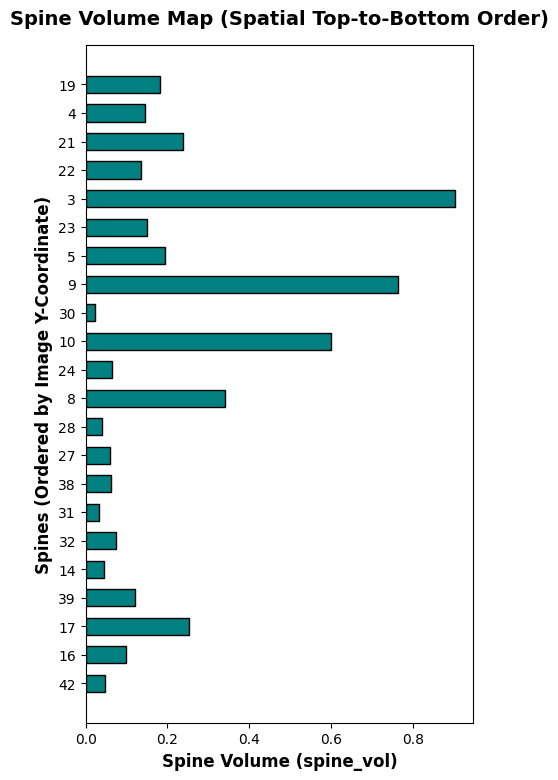

In [23]:
df = pd.read_csv(csv_path)

# 2. Convert coordinates and values to numeric floats (handles decimals gracefully)
df[y_coord_column] = pd.to_numeric(df[y_coord_column], errors='coerce')
df[value_column] = pd.to_numeric(df[value_column], errors='coerce')

# Drop rows missing crucial plotting or sorting data
df = df.dropna(subset=[value_column, label_column, y_coord_column])

# Convert IDs/Labels to clean strings
df[label_column] = df[label_column].astype(int).astype(str)

# 3. Sort the data based on the physical Y pixel coordinate.
# Ascending=True puts the lowest pixel value (top of your image) at the top of the plot.
df = df.sort_values(by=y_coord_column, ascending=True)

# Create a descriptive display label showing both ID and its spatial Y position
df['display_label'] = df.apply(
    lambda r: f"Spine {r[label_column]} (Y: {int(r[y_coord_column])})", axis=1
)
    
df
# 4. Dynamically set the plot height to keep labels clean
plot_height = max(5, len(df) * 0.4) 
fig, ax = plt.subplots(figsize=(5, plot_height))

# 5. Create the horizontal bar chart
bars = ax.barh(
    df['spine_id'], 
    df[value_column], 
    color='teal', 
    edgecolor='black', 
    height=0.6
)
ax.invert_yaxis()
ax.set_xlabel(f"Spine Volume ({value_column})", fontsize=12, fontweight='bold')
ax.set_ylabel("Spines (Ordered by Image Y-Coordinate)", fontsize=12, fontweight='bold')
ax.set_title("Spine Volume Map (Spatial Top-to-Bottom Order)", fontsize=14, fontweight='bold', pad=15)

plt.savefig(output_plot_path, dpi=300)



In [35]:
tempvar = df.columns[-11:-2]

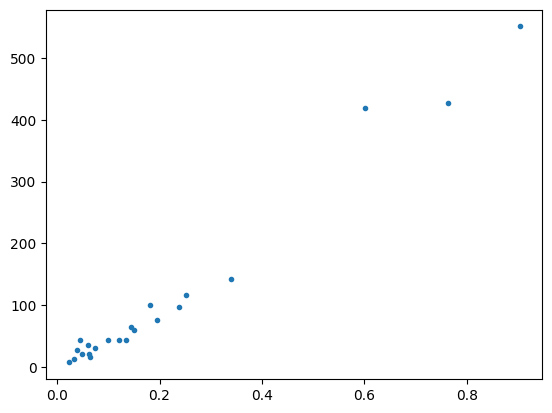

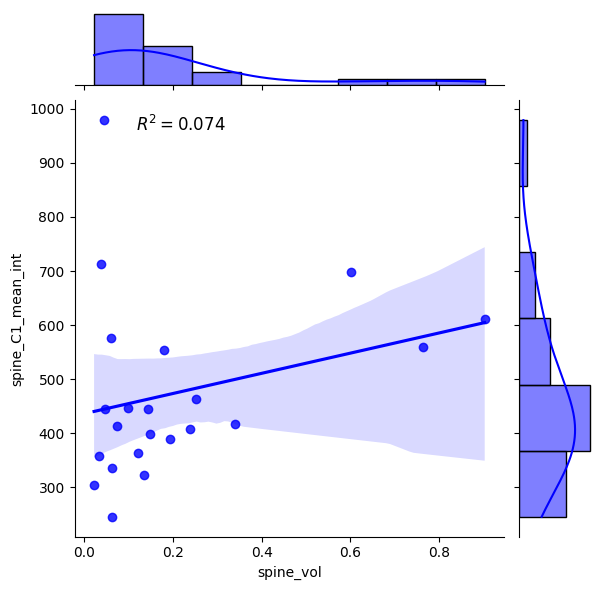

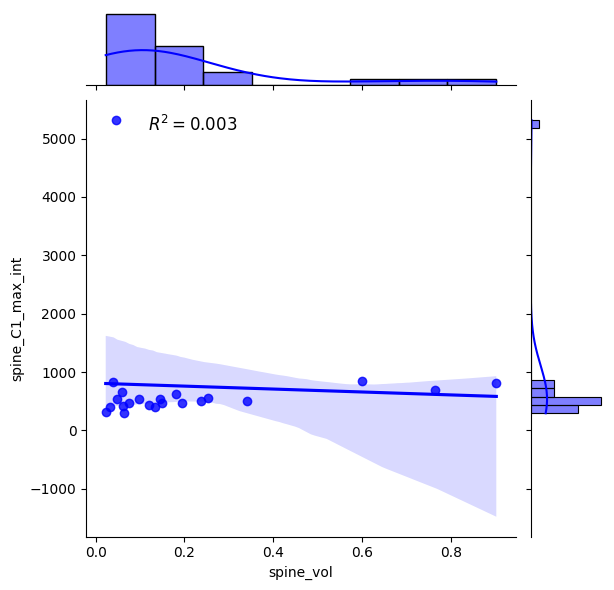

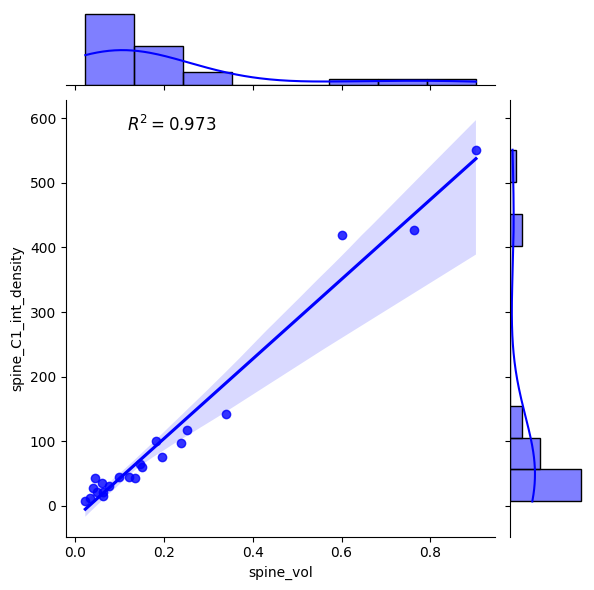

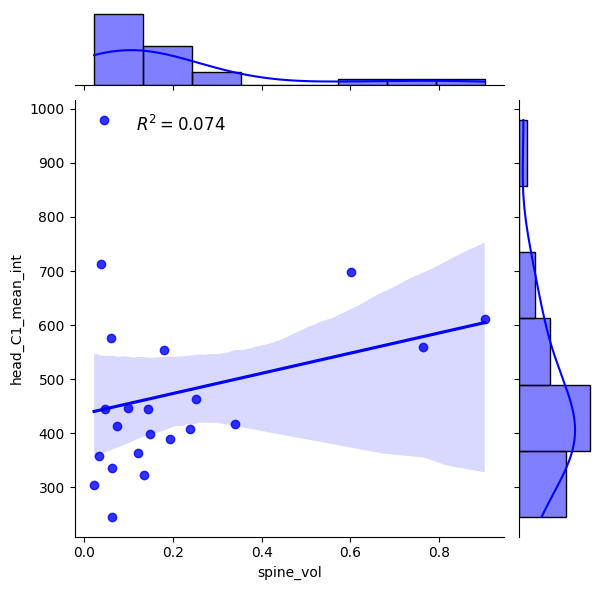

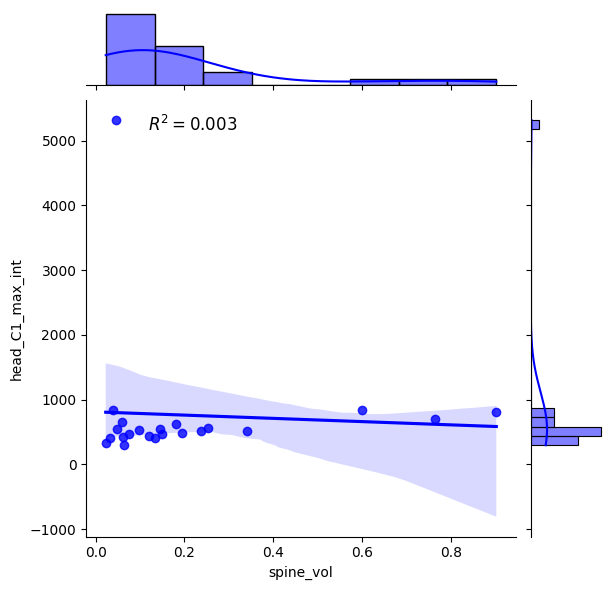

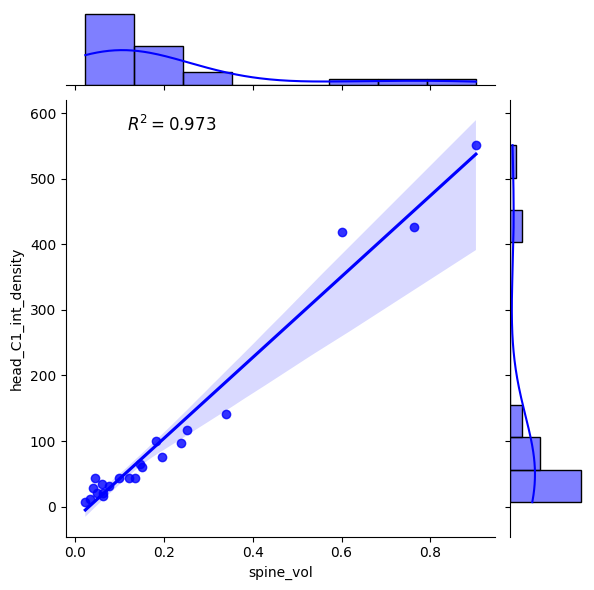

C:\Users\Windows\AppData\Local\Temp\ipykernel_10184\1352679213.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_val, _ = pearsonr(df[var1], df[var2])


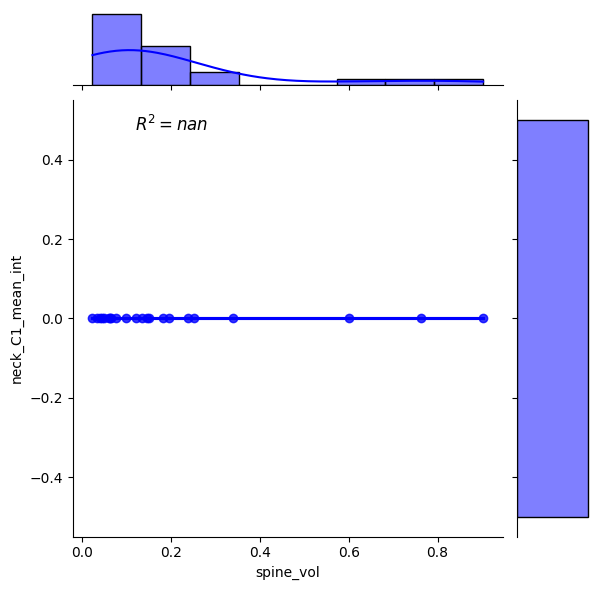

C:\Users\Windows\AppData\Local\Temp\ipykernel_10184\1352679213.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_val, _ = pearsonr(df[var1], df[var2])


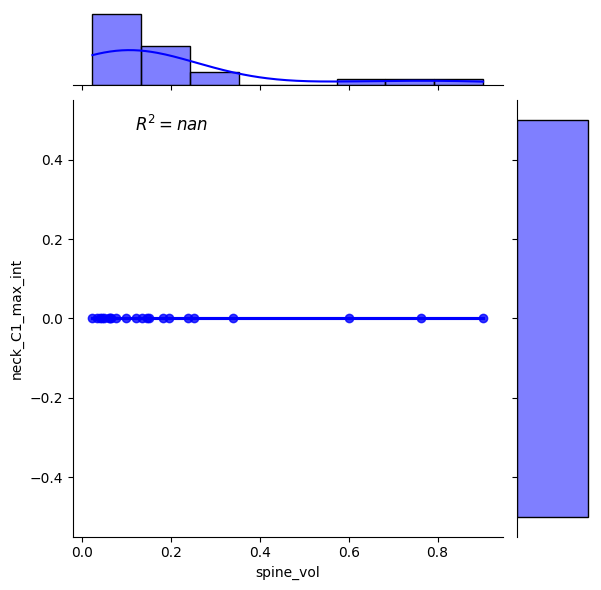

C:\Users\Windows\AppData\Local\Temp\ipykernel_10184\1352679213.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_val, _ = pearsonr(df[var1], df[var2])


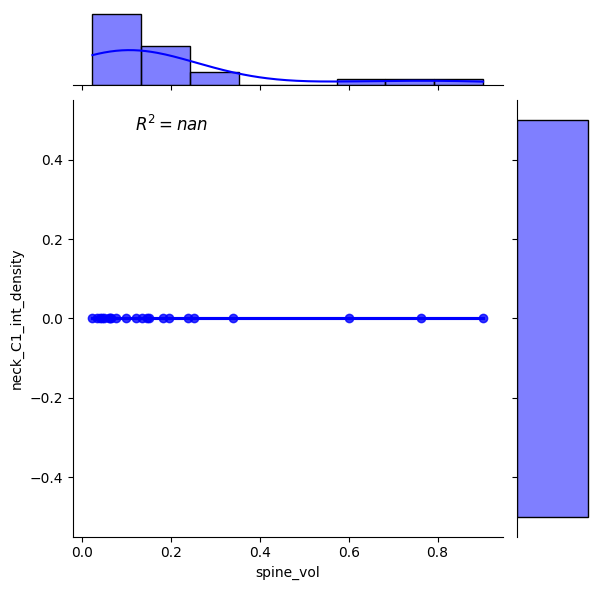

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
plt.plot(df['spine_vol'], df['spine_C1_int_density'], '.')

var1 = 'spine_vol'
var2 = 'spine_C1_int_density'

for var2 in tempvar:
    r_val, _ = pearsonr(df[var1], df[var2])
    r_sq = r_val ** 2

    # 3. Create the Seaborn plot
    g = sns.jointplot(x=var1, y=var2, data=df, kind='reg', color='b')

    # 4. Annotate the R² value onto the plot
    # We overlay the text on the joint axis (the main scatter plot)
    phantom_artist = g.ax_joint.plot([], [], linestyle="", label=f"$R^2 = {r_sq:.3f}$")
    g.ax_joint.legend(handles=phantom_artist, loc="upper left", frameon=False, fontsize=12)

    plt.show()